# Tiền xử lý dữ liệu dạng bảng

## Import các thư viện cần thiết

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Đọc dữ liệu

In [12]:
# Name of columns
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Read file
DATA_PATH = "../data/tabular-data/"
train_df = pd.read_csv(DATA_PATH + 'adult.data', names=column_names, sep=',', skipinitialspace=True)
test_df = pd.read_csv(DATA_PATH + 'adult.test', names=column_names, sep=',', skipinitialspace=True, skiprows=1)

print(train_df.shape)
train_df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


**Insights:**

- Dữ liệu có **32561** dòng và **15** cột.

- Mỗi dòng đại diện cho thông tin nhân khẩu học của một cá nhân.

- Ý nghĩa của các cột (thuộc tính) là:

    - `age`: Tuổi của cá nhân.

    - `workclass`: Loại công việc của cá nhân

    - `fnlwgt`: Trọng số cuối cùng, đại diện cho số lượng người mà dòng dữ liệu đại diện trong dân số thực tế.

    - `education`: Trình độ học vấn.

    - `education-num`: Số năm đi học tương úng với trình độ học vấn ở dạng số.

    - `marital-status`: Tình trạng hôn nhân.

    - `occupation`: Nghề nghiệp cụ thể.

    - `relationship`: Mối quan hệ trong gia đình.

    - `race`: Chủng tộc.

    - `sex`: Giới tính.

    - `capital-gain`: Thu nhập từ việc bán tài sản.

    - `capital-loss`: Khoản lỗ từ việc bán tài sản.

    - `hours-per-week`: Số giờ làm việc trung bình mỗi tuần.

    - `native-country`: Quốc gia quê quán.

    - `income`: Tổng thu nhập - Biến mục tiêu. 

# Biểu đồ phân phối của các biến dữ liệu

### Phân phối của biến mục tiêu `income`

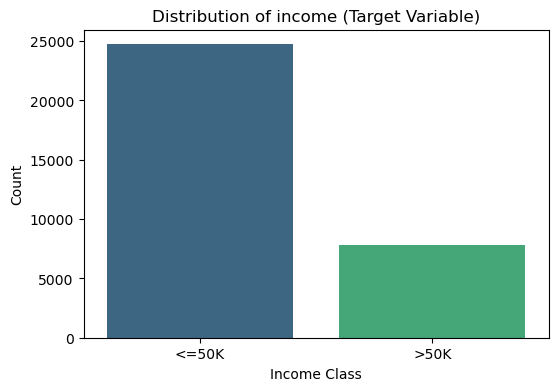

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=train_df, palette='viridis', hue='income', legend=False)
plt.title('Distribution of income (Target Variable)')
plt.xlabel('Income Class')
plt.ylabel('Count')
plt.show()

**Insights:**

- Dữ liệu không cân bằng (Imbalanced data) giữa các lớp.

### Biểu đồ phân phối của các cột có dữ liệu số

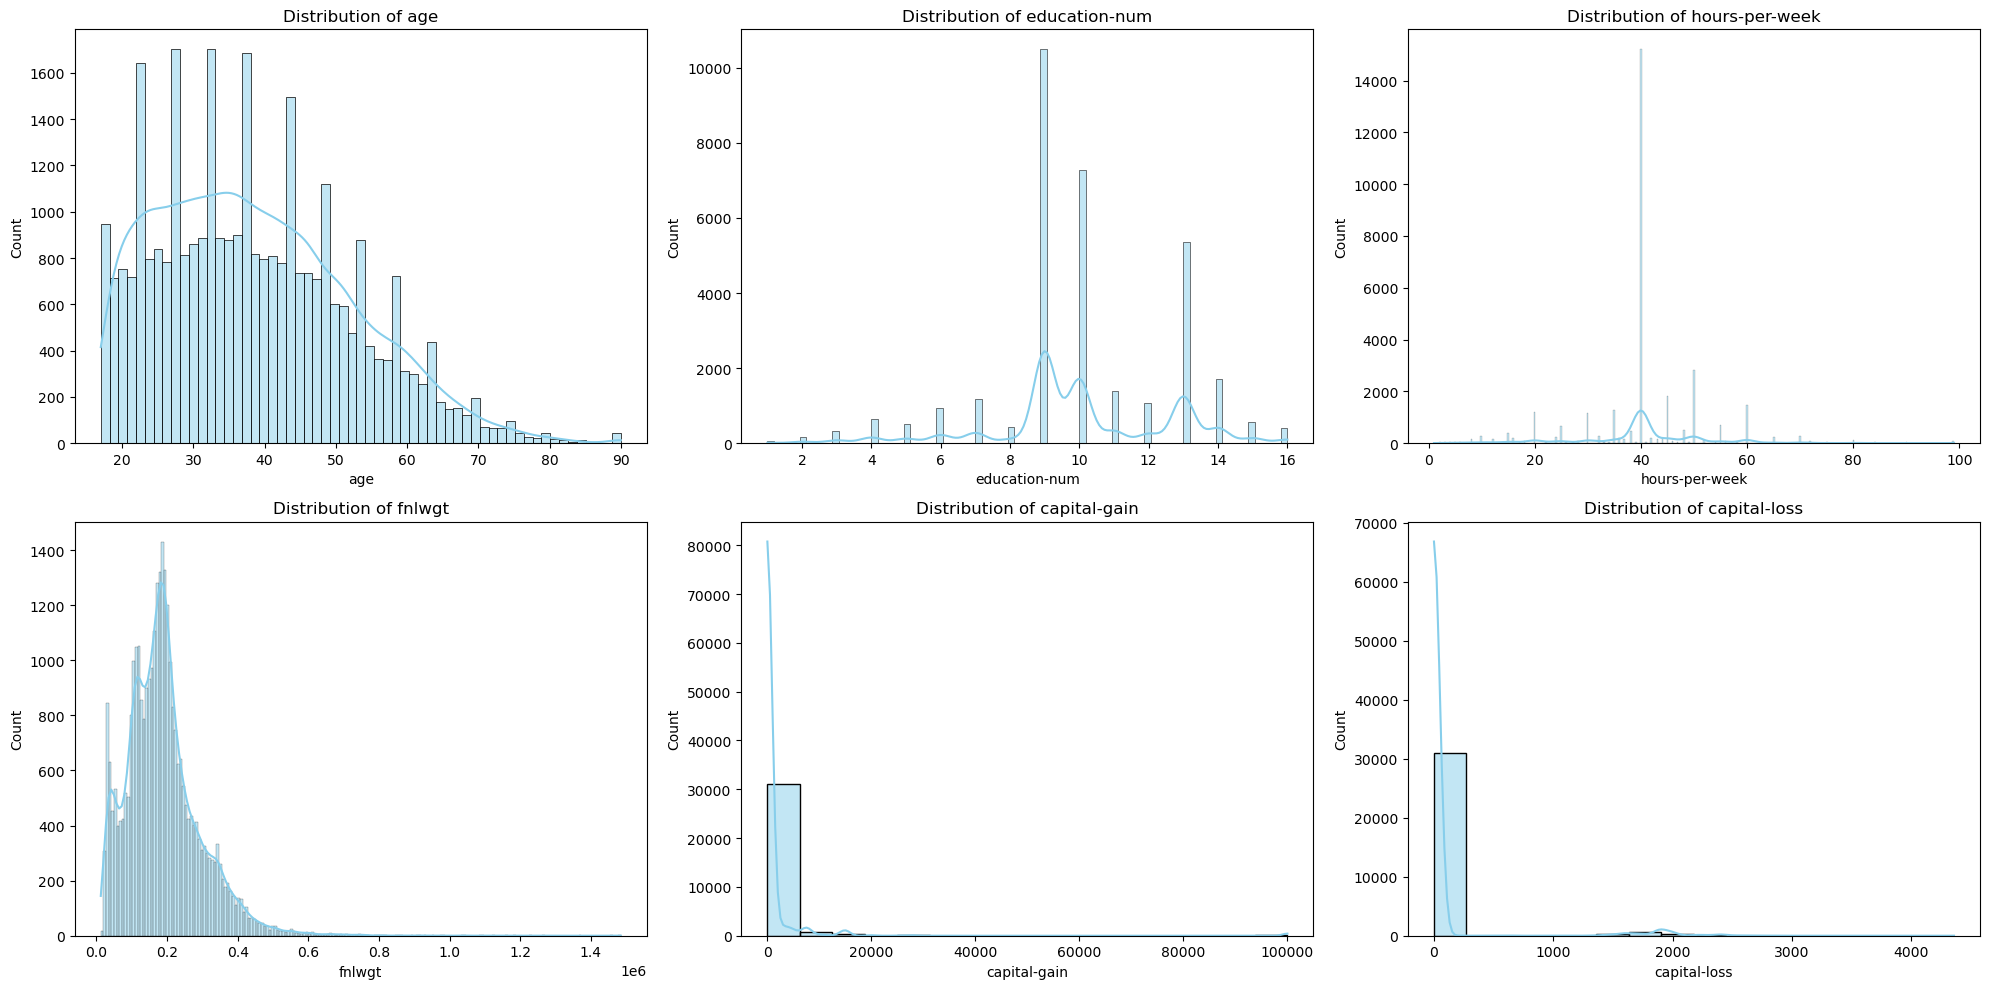

In [35]:
# Numeric features to plot
num_features = ['age', 'education-num', 'hours-per-week', 'fnlwgt', 'capital-gain', 'capital-loss']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
for i, col in enumerate(num_features):
    sns.histplot(train_df[col], kde=True, ax=axes.flat[i], color='skyblue')
    axes.flat[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# num_features = ['fnlwgt', 'capital-gain', 'capital-loss']

# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
# for i, col in enumerate(num_features):
#     sns.histplot(train_df[col], kde=True, ax=axes[i], color='skyblue')
#     axes[i].set_title(f'Distribution of {col}')

# plt.tight_layout()
# plt.show()

**Insights:**

- Phân phối tuổi (age):

    - Dữ liệu có dạng lệch phải (Right-skewed). Phần lớn các cá nhân nằm trong độ tuổi từ 20 đến 50. Số lượng người lao động giảm dần khi độ tuổi tăng cao (sau 60 tuổi).

- Số năm đi học (education-num):

    - Dữ liệu không liên tục mà tập trung thành các cột nhọn (multimodal). Đỉnh cao nhất nằm ở mức 9 (tương ứng với HS-grad) và các mức 10, 13.

- Số giờ làm việc mỗi tuần (hours-per-week):

    - Có cột cao nhất ngay tại giá trị 40. Điều này phản ánh thực tế thị trường lao động với chế độ làm việc 40 giờ/tuần.

- Trọng số cuối cùng (fnlwgt):

    - Đây là biểu đồ có độ lệch phải rất cực đoan. Hầu hết các giá trị tập trung ở mức thấp, nhưng có một vài "đuôi" kéo dài đến tận 1.4 triệu.

- Lợi nhuận và Thua lỗ vốn (capital-gain & capital-loss):

    - Hầu hết các giá trị đều tập trung ở 0. 

### Biểu đồ phân phối của các cột dữ liệu phân loại

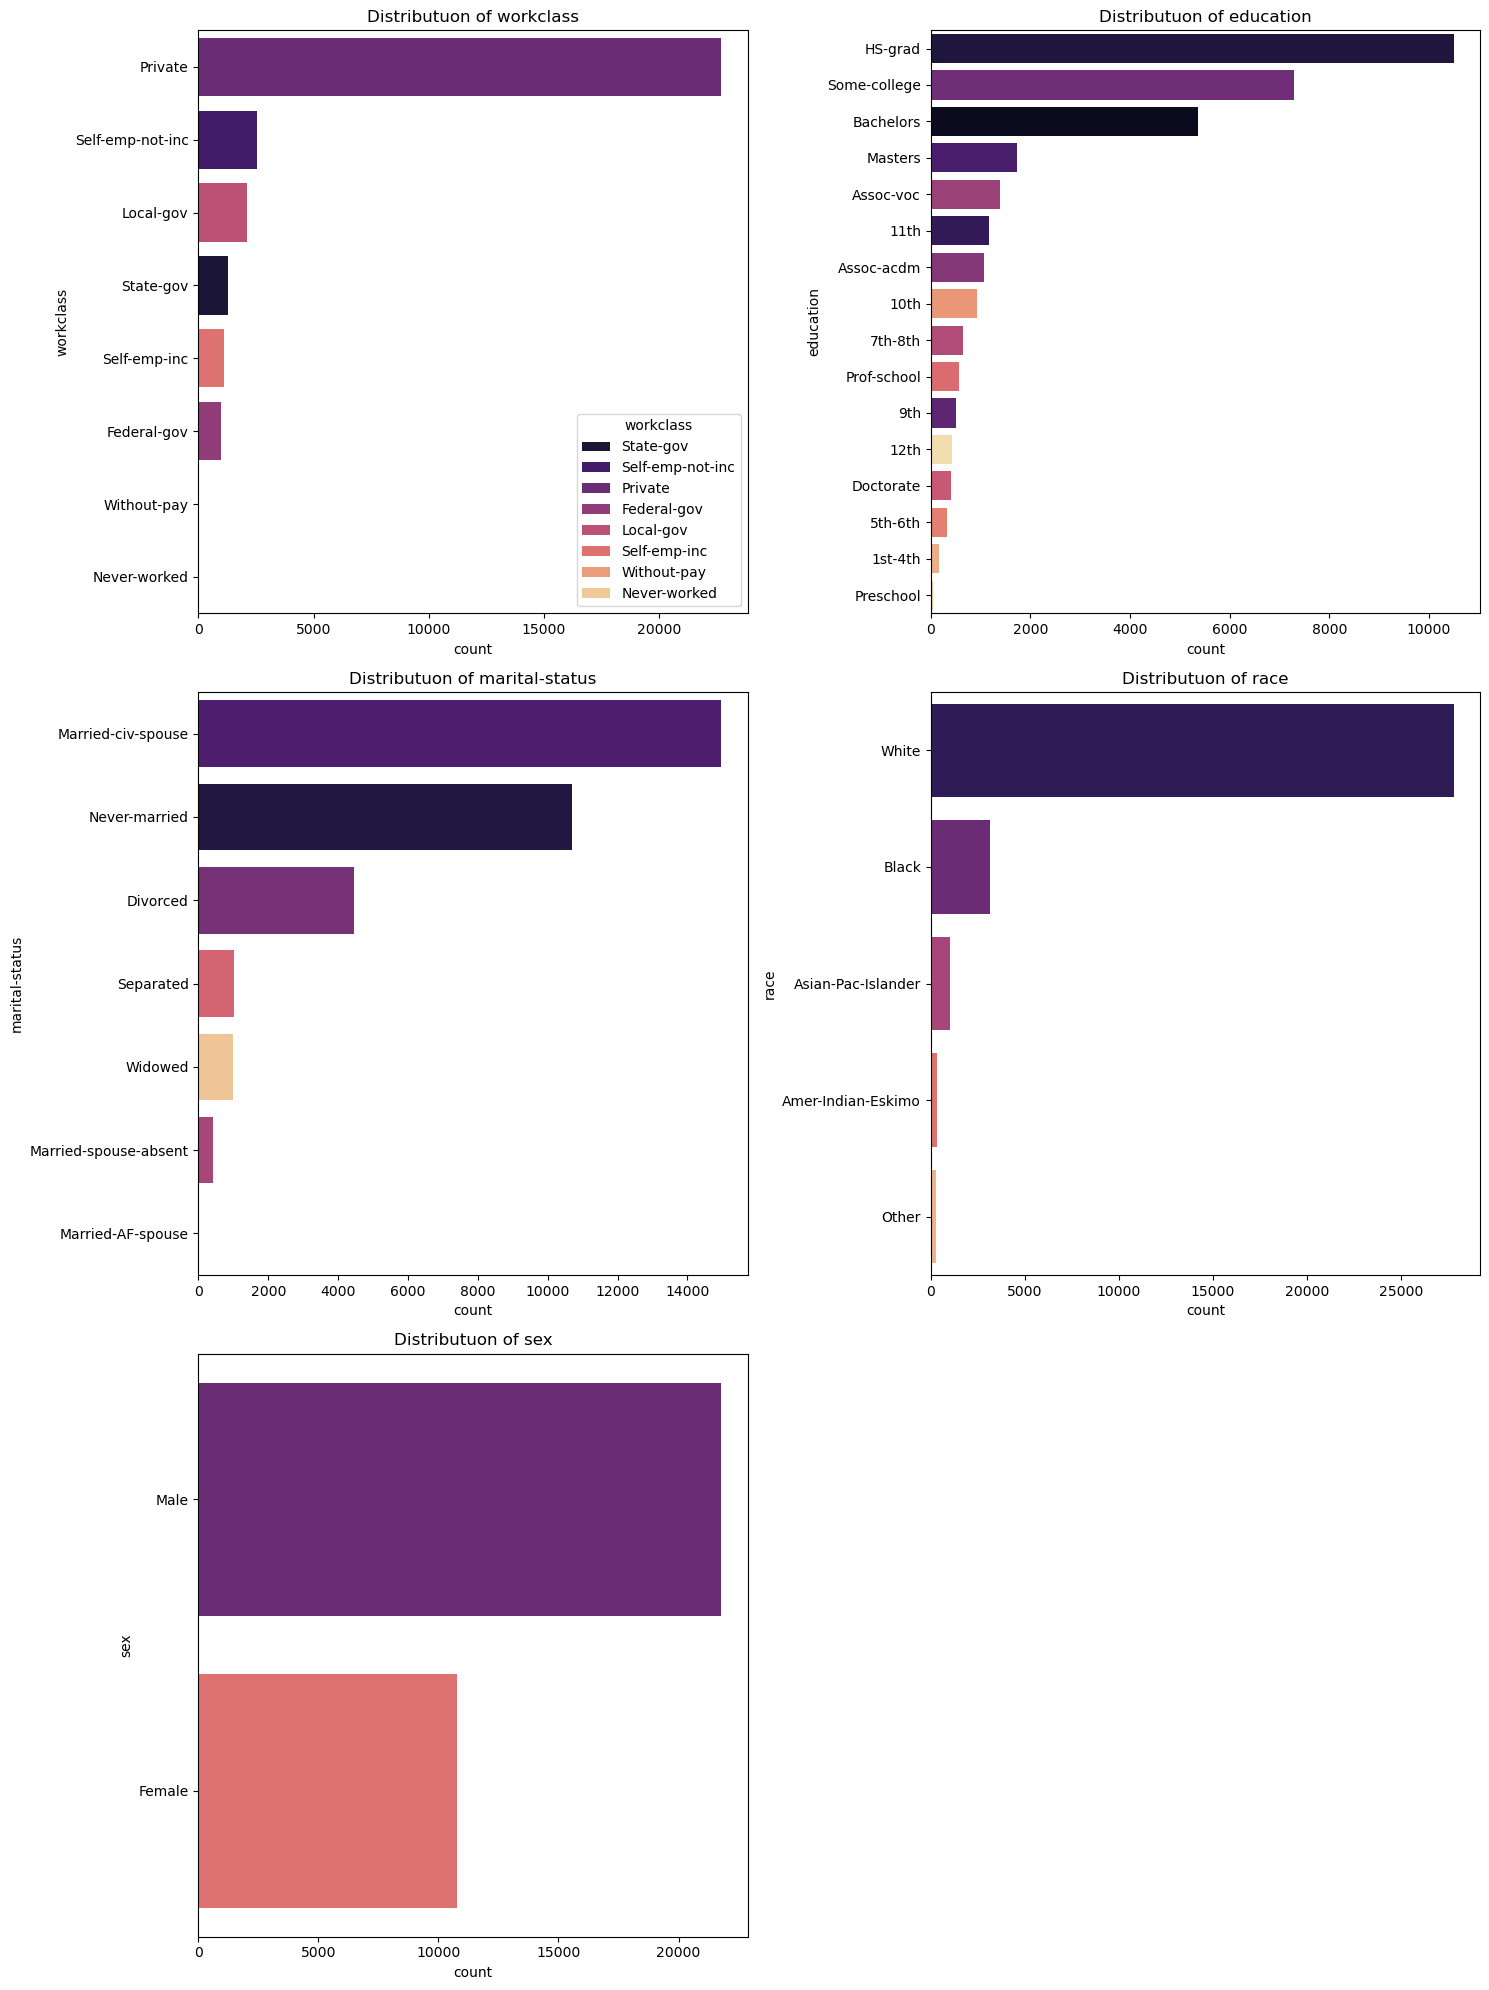

In [36]:
cat_features = ['workclass', 'education', 'marital-status', 'race', 'sex']

plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_features):
    plt.subplot(3, 2, i+1)
    sns.countplot(y=col, data=train_df, order=train_df[col].value_counts().index, hue=col, palette='magma')
    plt.title(f'Distributuon of {col}')
    plt.tight_layout()

plt.show()

**Insights:**

- `Workclass` bị lệch rất mạnh về nhóm Private, các nhóm còn lại chiếm tỷ trọng nhỏ.

- `Education` tập trung cao ở HS-grad, Some-college và Bachelors; các bậc rất thấp hoặc rất cao là nhóm hiếm.

- `Marital-status` chủ yếu là Married-civ-spouse và Never-married, tạo ra 2 cụm dân số lớn khá rõ.

- `Race` mất cân bằng rất nặng, nhóm White áp đảo; các nhóm khác là thiểu số rõ rệt.

- `Sex` cũng mất cân bằng, Male nhiều hơn Female đáng kể.

## Kiểm tra các giá trị thiếu (Mising values)

In [14]:
# Replace '?' with NaN
train_df.replace('?', np.nan, inplace=True)

# Number of missing values in each columns
print("Number of missing values in each columns")
print(train_df.isnull().sum())

Number of missing values in each columns
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


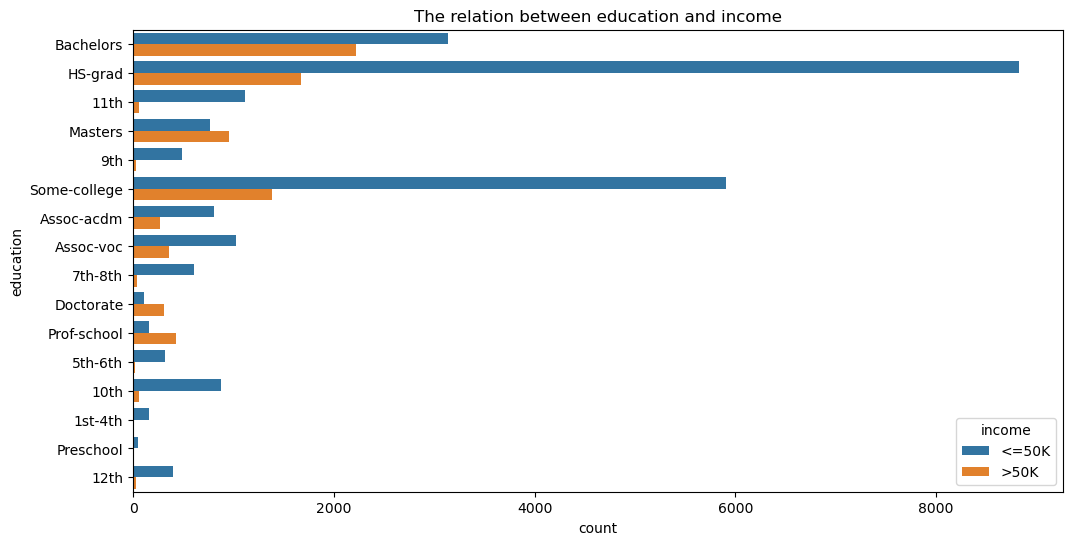

In [16]:
# The relation between education and income
plt.figure(figsize=(12,6))
sns.countplot(y='education', hue='income', data=train_df)
plt.title('The relation between education and income')
plt.show()